In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [28]:
!git clone https://github.com/philippwaleria1-blip/steam-ml-project.git

Cloning into 'steam-ml-project'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 25 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 5.93 MiB | 13.31 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [29]:
%cd steam-ml-project

/content/steam-ml-project/steam-ml-project


In [30]:
import os
os.listdir()

['.git', 'ml_steam.ipynb', 'steam.csv', 'README.md', 'Presentation.pdf']

In [31]:
import pandas as pd

df = pd.read_csv("steam.csv")

In [32]:
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

(27075, 18)

In [33]:
df.describe()

,appid,english,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price
count,2.707500e+04,27075.000000,27075.000000,27075.000000,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000
mean,5.962035e+05,0.981127,0.354903,45.248864,1.000559e+03,211.027147,149.804949,146.05603,6.078193
std,2.508942e+05,0.136081,2.406044,352.670281,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922
min,1.000000e+01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,4.012300e+05,1.000000,0.000000,0.000000,6.000000e+00,2.000000,0.000000,0.00000,1.690000
50%,5.990700e+05,1.000000,0.000000,7.000000,2.400000e+01,9.000000,0.000000,0.00000,3.990000
75%,7.987600e+05,1.000000,0.000000,23.000000,1.260000e+02,42.000000,0.000000,0.00000,7.190000
max,1.069460e+06,1.000000,18.000000,9821.000000,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000


In [34]:
df.isnull().sum()

,0
appid,0
name,0
release_date,0
english,0
developer,1
publisher,14
platforms,0
required_age,0
categories,0
genres,0


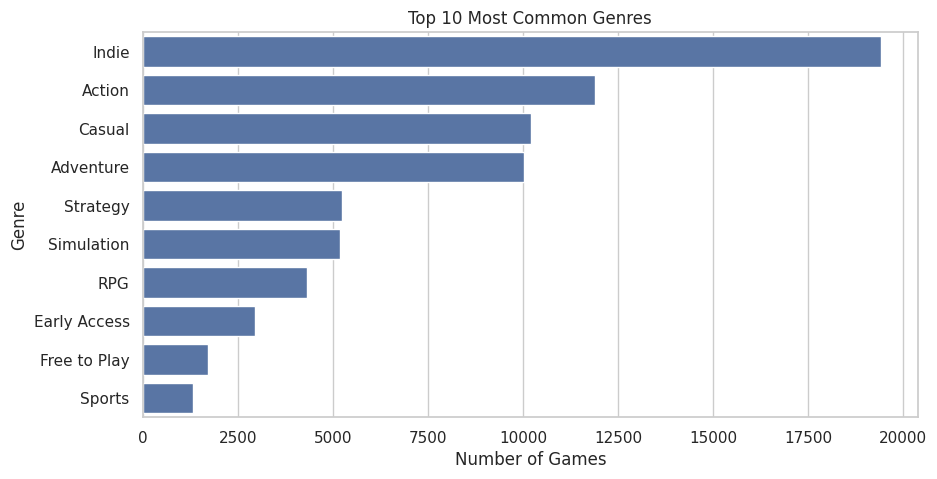

In [35]:
genres = (
    df["genres"]
    .str.split(";")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=genres.values,
    y=genres.index
)

plt.title("Top 10 Most Common Genres")
plt.xlabel("Number of Games")
plt.ylabel("Genre")

plt.show()

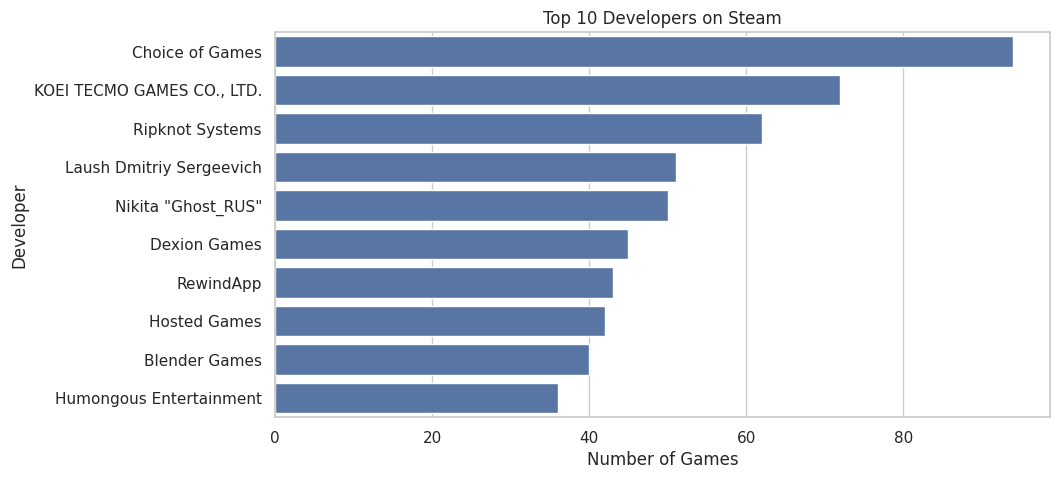

In [36]:
top_developers = df["developer"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_developers.values,
    y=top_developers.index
)

plt.title("Top 10 Developers on Steam")
plt.xlabel("Number of Games")
plt.ylabel("Developer")

plt.show()

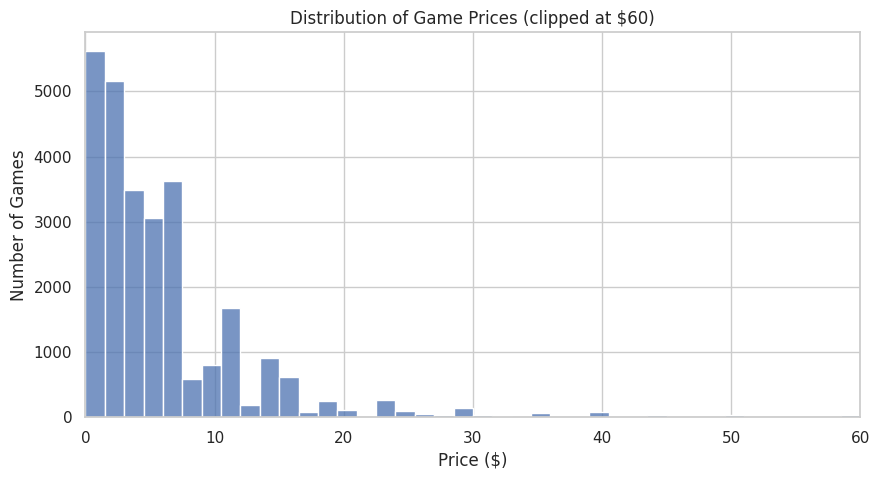

In [42]:
plt.figure(figsize=(10,5))

sns.histplot(df["price"].clip(upper=60), bins=40)

plt.title("Distribution of Game Prices (clipped at $60)")
plt.xlabel("Price ($)")
plt.ylabel("Number of Games")

plt.xlim(0, 60)

plt.show()

In [43]:
df["developer"] = df["developer"].fillna("Unknown")
df["publisher"] = df["publisher"].fillna("Unknown")

In [ ]:
df.duplicated().sum()

np.int64(0)

In [57]:
df["total_ratings"] = df["positive_ratings"] + df["negative_ratings"]

In [58]:
df["rating_ratio"] = df["positive_ratings"] / (df["positive_ratings"] + df["negative_ratings"])
df["rating_ratio"] = df["rating_ratio"].fillna(0)

In [59]:
df["log_ratings"] = np.log1p(df["total_ratings"])

In [60]:
df["is_free"] = (df["price"] == 0).astype(int)

In [61]:
df[["total_ratings", "rating_ratio", "log_ratings", "is_free"]].head()

,total_ratings,rating_ratio,log_ratings,is_free
0,127873,0.973888,11.758801,0
1,3951,0.839787,8.281977,0
2,3814,0.895648,8.246696,0
3,1540,0.826623,7.340187,0
4,5538,0.947996,8.619569,0


In [62]:
df[["total_ratings", "rating_ratio", "log_ratings", "is_free"]].describe()

,total_ratings,rating_ratio,log_ratings,is_free
count,2.707500e+04,27075.000000,27075.000000,27075.000000
mean,1.211586e+03,0.714478,3.928539,0.094552
std,2.242909e+04,0.233594,2.082908,0.292601
min,1.000000e+00,0.000000,0.693147,0.000000
25%,1.000000e+01,0.583333,2.397895,0.000000
50%,3.600000e+01,0.760331,3.610918,0.000000
75%,1.760000e+02,0.893905,5.176150,0.000000
max,3.046717e+06,1.000000,14.929576,1.000000


In [63]:
df.isnull().sum()

,0
appid,0
name,0
release_date,0
english,0
developer,0
publisher,0
platforms,0
required_age,0
categories,0
genres,0


In [64]:
df[["total_ratings", "rating_ratio", "log_ratings", "is_free"]].corr()

,total_ratings,rating_ratio,log_ratings,is_free
total_ratings,1.000000,0.025750,0.174562,0.035789
rating_ratio,0.025750,1.000000,0.164093,0.006338
log_ratings,0.174562,0.164093,1.000000,0.137480
is_free,0.035789,0.006338,0.137480,1.000000


In [65]:
cols_to_scale = ["price", "average_playtime", "median_playtime", "log_ratings"]
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df[cols_to_scale].head()

,price,average_playtime,median_playtime,log_ratings
0,0.141186,9.557829,0.072624,3.759362
1,-0.265175,0.069619,-0.035710,2.090116
2,-0.265175,0.020358,-0.047606,2.073177
3,-0.265175,0.059220,0.016120,1.637956
4,-0.265175,0.259548,0.114258,2.252196


In [66]:
X_raw = df[["price", "average_playtime", "median_playtime"]]
y = (df["positive_ratings"] > df["positive_ratings"].median())

In [67]:
X_feat = df[["price", "average_playtime", "median_playtime",
             "rating_ratio", "log_ratings", "is_free"]]

In [70]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)
Xf_train, Xf_test, yf_train, yf_test = train_test_split(X_feat, y, test_size=0.2, random_state=42)

In [71]:

model1 = LogisticRegression(max_iter=1000)
model1.fit(Xr_train, yr_train)
pred1 = model1.predict(Xr_test)

acc_raw = accuracy_score(yr_test, pred1)
acc_raw

0.6958448753462604

In [72]:
model2 = LogisticRegression(max_iter=1000)
model2.fit(Xf_train, yf_train)
pred2 = model2.predict(Xf_test)

acc_feat = accuracy_score(yf_test, pred2)
acc_feat

0.9931671283471838

In [73]:
print("Accuracy bez feature engineering:", acc_raw)
print("Accuracy z feature engineering:", acc_feat)

Accuracy bez feature engineering: 0.6958448753462604
Accuracy z feature engineering: 0.9931671283471838


In [74]:
y = (df["positive_ratings"] > df["positive_ratings"].median())
X = df[["price", "average_playtime", "median_playtime", "rating_ratio", "log_ratings", "is_free"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

pred_dummy = dummy.predict(X_test)

acc_dummy = accuracy_score(y_test, pred_dummy)
acc_dummy

0.4965835641735919

In [76]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)
acc_rf

0.9987072945521699

In [77]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
pred_best = best_model.predict(X_test)

acc_best = accuracy_score(y_test, pred_best)

grid.best_params_, acc_best

({'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50},
 0.997229916897507)

In [82]:
print("Dummy:", acc_dummy)
print("Logistic Regression:", acc_feat)
print("Random Forest:", acc_rf)
print("Best RF (GridSearch):", acc_best)

Dummy: 0.4965835641735919
Logistic Regression: 0.9931671283471838
Random Forest: 0.9987072945521699
Best RF (GridSearch): 0.997229916897507


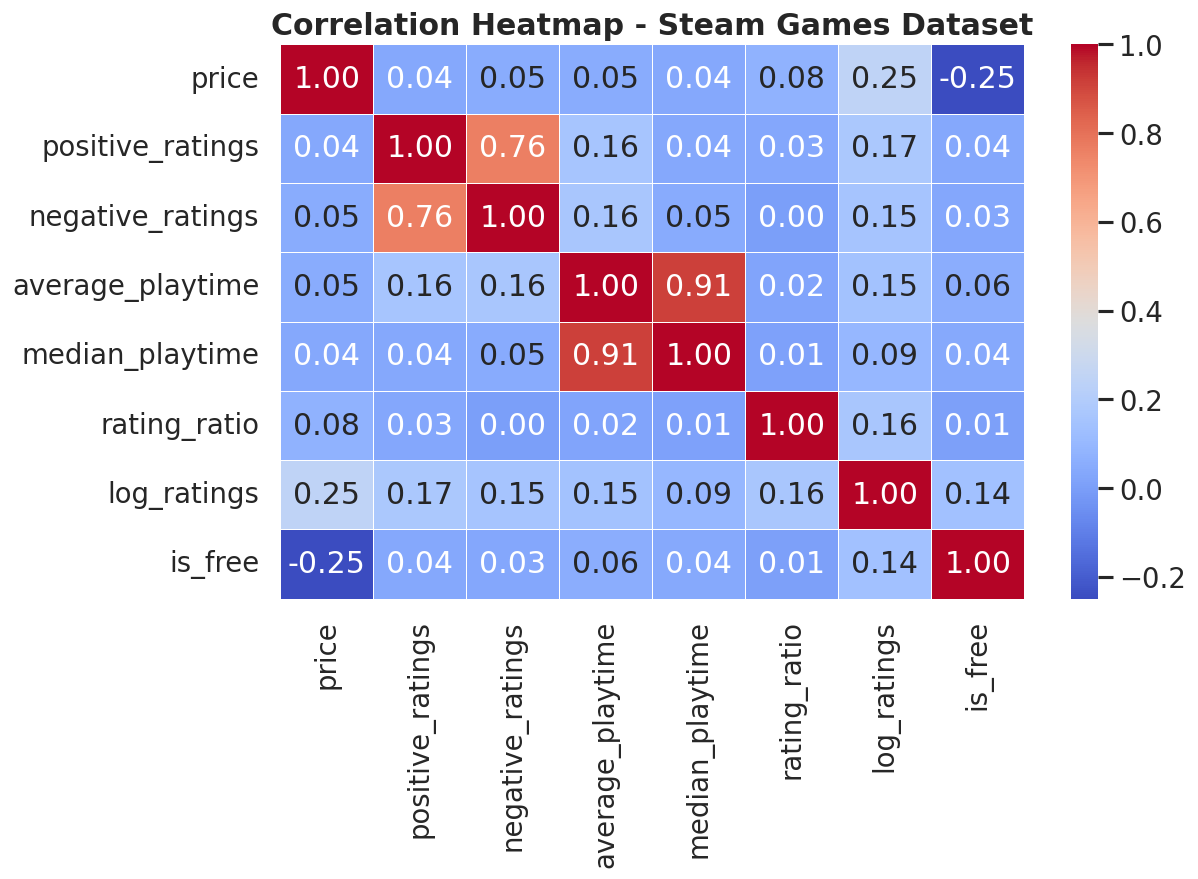

In [ ]:
plt.figure(figsize=(10,6))

cols = [
    "price",
    "positive_ratings",
    "negative_ratings",
    "average_playtime",
    "median_playtime",
    "rating_ratio",
    "log_ratings",
    "is_free"
]

corr = df[cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap - Steam Games Dataset")
plt.show()

W pierwszej wersji projektu zastosowano cechy pochodne, takie jak rating_ratio, total_ratings oraz log_ratings, które były bezpośrednio lub pośrednio oparte na liczbie pozytywnych i negatywnych ocen użytkowników. W trakcie analizy okazało się, że cechy te są zbyt silnie powiązane ze zmienną docelową, co prowadziło do zjawiska data leakage. W efekcie modele uzyskiwały nienaturalnie wysokie wyniki dokładności (nawet powyżej 0.99), które nie odzwierciedlały rzeczywistej zdolności predykcyjnej modelu, lecz wynikały z „podpowiedzi” zawartych w danych wejściowych.

In [44]:
df["is_free"] = (df["price"] == 0).astype(int)

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

df["game_age"] = 2025 - df["release_year"]

df["has_achievements"] = (df["achievements"] > 0).astype(int)

df["is_adult"] = (df["required_age"] >= 18).astype(int)

In [45]:
X_new = df[
    [
        "price",
        "average_playtime",
        "median_playtime",
        "is_free",
        "game_age",
        "has_achievements",
        "is_adult"
    ]
]

In [86]:
y2 = (df["positive_ratings"] > df["positive_ratings"].median())

In [87]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_new, y2, test_size=0.2, random_state=42
)

In [89]:
dummy2 = DummyClassifier(strategy="most_frequent")
dummy2.fit(X_train2, y_train2)
acc_dummy2 = accuracy_score(y_test2, dummy2.predict(X_test2))
print("Dummy accuracy:", acc_dummy2)

Dummy accuracy: 0.4965835641735919


In [100]:
lr2 = LogisticRegression(max_iter=1000)
lr2.fit(X_train2, y_train2)
acc_lr2 = accuracy_score(y_test2, lr2.predict(X_test2))
print("Accuracy bez feature engineering:", acc_raw)
print("Accuracy z feature engineering(po nowych cechach) :", acc_lr2)

Accuracy bez feature engineering: 0.6958448753462604
Accuracy z feature engineering(po nowych cechach) : 0.7667590027700831


In [93]:
rf2 = RandomForestClassifier(random_state=42)
rf2.fit(X_train2, y_train2)
acc_rf2 = accuracy_score(y_test2, rf2.predict(X_test2))
print("Random Forest2 accuracy:", acc_rf2)

Random Forest2 accuracy: 0.7706371191135734


In [95]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
pred_best = best_model.predict(X_test)

acc_best2 = accuracy_score(y_test2, best_model.predict(X_test2))

print("Best RF (GridSearch) accuracy:", acc_best2)

Best RF (GridSearch) accuracy: 0.7802400738688827


In [96]:
print("Dummy Classifier:", acc_dummy2)
print("Logistic Regression:", acc_lr2)
print("Random Forest:", acc_rf2)
print("Random Forest (GridSearch):", acc_best2)

Dummy Classifier: 0.4965835641735919
Logistic Regression: 0.7667590027700831
Random Forest: 0.7706371191135734
Random Forest (GridSearch): 0.7802400738688827


In [99]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "GridSearch"
    ],
    "Old features": [
        acc_lr,
        acc_rf,
        acc_best
    ],
    "New features": [
        acc_lr2,
        acc_rf2,
        acc_best2
    ]
})

results

,Model,Old features,New features
0,Logistic Regression,0.993167,0.766759
1,Random Forest,0.998707,0.770637
2,GridSearch,0.997230,0.780240
